In [1]:
# ============================================================
# Package versions
# ============================================================
# Python:      3.9.23
# NumPy:       2.0.2
# pandas:      2.3.3
# PyTorch:     2.8.0+cu126
# seaborn:     0.13.2
# matplotlib:  3.9.4
# UMAP:        0.5.9.post2
# scikit-learn:1.6.1
# scotplus:    1.0.2

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scotplus.solvers import SinkhornSolver
from scotplus.utils.alignment import compute_graph_distances, get_barycentre, FOSCTTM
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set seeds for Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Check device
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"CUDNN version: {torch.backends.cudnn.version()}")

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

Torch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
CUDNN version: 91002
Using device: cuda:0


In [5]:
# Paths setting
script_dir = os.getcwd()
IN_DIR = os.path.join(script_dir, "processed_data")
RNA_FILE = os.path.join(IN_DIR, "Processed_transcriptomics.csv")
PROT_FILE = os.path.join(IN_DIR, "Processed_proteomics.csv")
RNA_META = os.path.join(IN_DIR, "Processed_transcriptomics_metadata.csv")
PROT_META = os.path.join(IN_DIR, "Processed_proteomics_metadata.csv")
OUT_DIR = os.path.join(script_dir, "aligned_data")
os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
# Preprocessed data loading
rna_df = pd.read_csv(RNA_FILE, index_col=0)
prot_df = pd.read_csv(PROT_FILE, index_col=0)

rna = rna_df.T.copy()
prot = prot_df.T.copy()

print("RNA shape (samples x features):", rna.shape)
print("Proteomics shape (samples x features):", prot.shape)

# Sort samples for reproducibility
rna = rna.sort_index()
prot = prot.sort_index()

RNA shape (samples x features): (82, 1500)
Proteomics shape (samples x features): (68, 1500)


In [7]:
# Metadata loading
rna_meta = pd.read_csv(RNA_META)
prot_meta = pd.read_csv(PROT_META)

if "SampleID" not in rna_meta.columns or "SampleID" not in prot_meta.columns:
    raise ValueError("Both metadata files must contain a 'SampleID' column.")

rna_meta = rna_meta.set_index("SampleID")
prot_meta = prot_meta.set_index("SampleID")

# Subset to matrix sample order
missing_rna_meta = sorted(set(rna.index) - set(rna_meta.index))
missing_prot_meta = sorted(set(prot.index) - set(prot_meta.index))

if missing_rna_meta:
    raise ValueError(f"RNA metadata missing SampleID(s): {missing_rna_meta[:10]}")
if missing_prot_meta:
    raise ValueError(f"Proteomics metadata missing SampleID(s): {missing_prot_meta[:10]}")

rna_meta = rna_meta.loc[rna.index].copy()
prot_meta = prot_meta.loc[prot.index].copy()

print("\nRNA metadata preview:")
print(rna_meta.head())
print("\nProteomics metadata preview:")
print(prot_meta.head())

# Shared IDs for benchmark evaluation only
common_true = sorted(set(rna.index).intersection(set(prot.index)))
print("\nShared true paired sample count:", len(common_true))

if len(common_true) == 0:
    raise ValueError("No shared SampleID values between RNA and proteomics. Cannot benchmark with FOSCTTM.")


RNA metadata preview:
            Chip CellLine  DetectedGenes5  LibrarySize  sizeFactor
05J_C10_A10  05J      C10            4962      2463839    1.625119
05J_C10_A11  05J      C10            5755      2057977    1.391330
05J_C10_A2   05J      C10            5866      3988093    2.506477
05J_C10_A3   05J      C10            6044      2288517    1.637505
05J_C10_A4   05J      C10            6131      2295137    1.563822

Proteomics metadata preview:
            Chip CellLine  DetectedProteins
05J_C10_A10  05J      C10              2564
05J_C10_A11  05J      C10              2754
05J_C10_A2   05J      C10              2737
05J_C10_A3   05J      C10              2397
05J_C10_A4   05J      C10              2652

Shared true paired sample count: 61


In [8]:
# Keeping labels for UMPA projection use
if "CellLine" not in rna_meta.columns or "CellLine" not in prot_meta.columns:
    raise ValueError("Metadata must contain a 'CellLine' column for labels.")

rna_labels = rna_meta["CellLine"].to_numpy()
prot_labels = prot_meta["CellLine"].to_numpy()

print("\nRNA CellLine counts:")
print(pd.Series(rna_labels).value_counts())
print("\nProteomics CellLine counts:")
print(pd.Series(prot_labels).value_counts())

# Preserve names before matrix conversion
rna_features = rna.columns.to_numpy()
prot_features = prot.columns.to_numpy()
rna_cells = rna.index.to_numpy()
prot_cells = prot.index.to_numpy()


RNA CellLine counts:
C10     43
SVEC    39
Name: count, dtype: int64

Proteomics CellLine counts:
SVEC    37
C10     31
Name: count, dtype: int64


In [10]:
# NA Handling
print("\nNA counts before imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))

if rna.isna().sum().sum() > 0:
    warnings.warn("RNA contains NA values; filling feature-wise medians, then 0 if needed.")
    rna = rna.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

# Proteomics - feature-wise median imputation
if prot.isna().sum().sum() > 0:
    prot = prot.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

print("\nNA counts after imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))


NA counts before imputation:
RNA NA count: 0
Proteomics NA count: 20750

NA counts after imputation:
RNA NA count: 0
Proteomics NA count: 0


In [11]:
# Feature-wise scaling for SCOT+ geometry
rna_mtx = rna.to_numpy(dtype=np.float32)
prot_mtx = prot.to_numpy(dtype=np.float32)

rna_mtx = StandardScaler().fit_transform(rna_mtx).astype(np.float32)
prot_mtx = StandardScaler().fit_transform(prot_mtx).astype(np.float32)

assert np.isfinite(rna_mtx).all(), "RNA still contains NaN/Inf after scaling"
assert np.isfinite(prot_mtx).all(), "Proteomics still contains NaN/Inf after scaling"

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


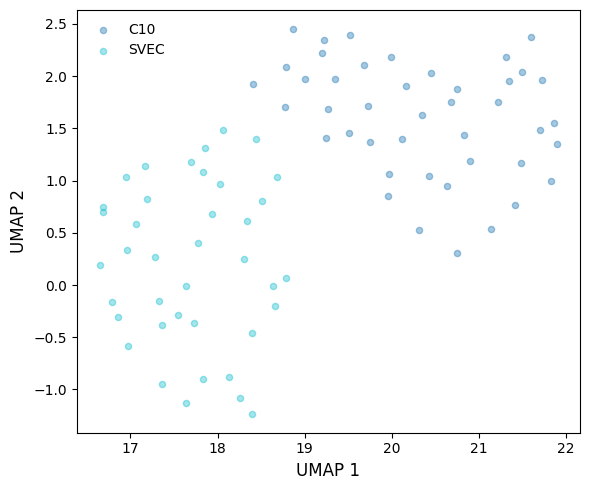

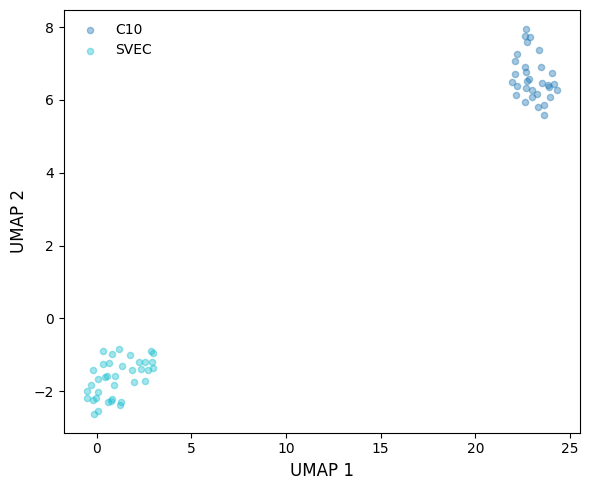

In [12]:
def scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=None, alpha_val=0.4):
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=alpha_val, color=label_to_color[label], label=label)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)

    if panel_label is not None:
        ax.text(-0.14, 1.05, panel_label, transform=ax.transAxes, fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)

def make_single_embedding(emb, labels, unique_labels, label_to_color, xlabel, ylabel, out_base, panel_label=None, alpha_svg=0.4, alpha_eps=1.0):
    # SVG version
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=panel_label, alpha_val=alpha_svg)
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

unique_labels = list(np.unique(np.concatenate([rna_labels, prot_labels])))
cmap = plt.get_cmap("tab10", len(unique_labels))
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}

rna_pca = PCA(n_components=2, random_state=SEED)
rna_2Dpca = rna_pca.fit_transform(rna_mtx)

prot_pca = PCA(n_components=2, random_state=SEED)
prot_2Dpca = prot_pca.fit_transform(prot_mtx)

#UMAP
rna_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
rna_2Dumap = rna_umap.fit_transform(rna_mtx)

prot_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
prot_2Dumap = prot_umap.fit_transform(prot_mtx)

make_single_embedding(rna_2Dumap, rna_labels, unique_labels, label_to_color, "UMAP 1", "UMAP 2",
                      os.path.join(OUT_DIR, "RNA_UMAP_before_alignment"))

make_single_embedding(prot_2Dumap, prot_labels, unique_labels, label_to_color, "UMAP 1", "UMAP 2",
                      os.path.join(OUT_DIR, "Proteomics_UMAP_before_alignment"))

In [13]:
# Sinkhorn solver initialisation
scot = SinkhornSolver(nits_uot=5000, tol_uot=1e-3, device=device)

In [14]:
#Function definition
def save_figure_both(fig, out_base):
    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")

In [24]:
# Epsilon grid search: computation only

RUN_EPS_GRID_SEARCH = True

manual_eps = 4.5e-2
eps_grid = [1e-3, 1e-2, 4.5e-2, 1e-1]
alpha_for_eps = 0.5
k_for_eps = 5

eps_results = []

if RUN_EPS_GRID_SEARCH:
    print("Running epsilon grid search...")

    D_rna_knn_eps = torch.from_numpy(compute_graph_distances(rna_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)

    D_prot_knn_eps = torch.from_numpy(compute_graph_distances(prot_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)

    for eps_try in eps_grid:
        print(f"\nRunning epsilon test: eps={eps_try}")

        eps_tag = f"{eps_try:.0e}".replace("+", "").replace("-", "m")
        out_npz = os.path.join(OUT_DIR, f"epsilon_{eps_tag}_couplings.npz")

        try:
            pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn_eps, D_prot_knn_eps, alpha=alpha_for_eps, eps=eps_try, verbose=True)

            pi_samp_np = (pi_samp.detach().cpu().numpy() if hasattr(pi_samp, "detach") else np.array(pi_samp))

            pi_feat_np = (pi_feat.detach().cpu().numpy() if hasattr(pi_feat, "detach") else np.array(pi_feat))

            np.savez_compressed(out_npz, eps=eps_try, alpha=alpha_for_eps, k=k_for_eps, pi_samp=pi_samp_np, pi_feat=pi_feat_np)

            eps_results.append({
                "eps": eps_try,
                "alpha": alpha_for_eps,
                "k": k_for_eps,
                "status": "success",
                "npz_file": out_npz,
                "sample_coupling_shape": str(pi_samp_np.shape),
                "feature_coupling_shape": str(pi_feat_np.shape)
            })

            print(f"Saved couplings to: {out_npz}")

        except Exception as e:
            print(f"Failed for eps={eps_try}: {e}")

            eps_results.append({
                "eps": eps_try,
                "alpha": alpha_for_eps,
                "k": k_for_eps,
                "status": f"failed: {e}",
                "npz_file": "",
                "sample_coupling_shape": "",
                "feature_coupling_shape": ""
            })

    eps_results_df = pd.DataFrame(eps_results)
    eps_results_df.to_csv(os.path.join(OUT_DIR, "epsilon_grid_search_log.csv"), index=False)

    print("\nEpsilon grid search completed.")
    print("Saved epsilon-grid results to:", OUT_DIR)

else:
    print("Skipping epsilon grid search.")

eps = manual_eps
print(f"\nSelected eps for downstream analysis: {eps}")

Running epsilon grid search...

Running epsilon test: eps=0.001
BCD Iteration 1 - Loss: 0.737022, 0.744771
BCD Iteration 2 - Loss: 0.675439, 0.684165
BCD Iteration 3 - Loss: 0.668620, 0.677400
BCD Iteration 4 - Loss: 0.665383, 0.674182
BCD Iteration 5 - Loss: 0.664960, 0.673761
BCD Iteration 6 - Loss: 0.664285, 0.673086
BCD Iteration 7 - Loss: 0.664176, 0.672981
BCD Iteration 8 - Loss: 0.664193, 0.673001
BCD Iteration 9 - Loss: 0.664056, 0.672873
BCD Iteration 10 - Loss: 0.663956, 0.672776
BCD Iteration 11 - Loss: 0.663600, 0.672417
BCD Iteration 12 - Loss: 0.663565, 0.672386
BCD Iteration 13 - Loss: 0.663621, 0.672442
BCD Iteration 14 - Loss: 0.663633, 0.672454
BCD Iteration 15 - Loss: 0.663629, 0.672448
Saved couplings to: C:\Users\49152\Downloads\Multi-omics\Script\For_repositories\aligned_data\epsilon_1em03_couplings.npz

Running epsilon test: eps=0.01
BCD Iteration 1 - Loss: 0.853303, 0.888369
BCD Iteration 2 - Loss: 0.750067, 0.811098
BCD Iteration 3 - Loss: 0.684075, 0.757422
BC

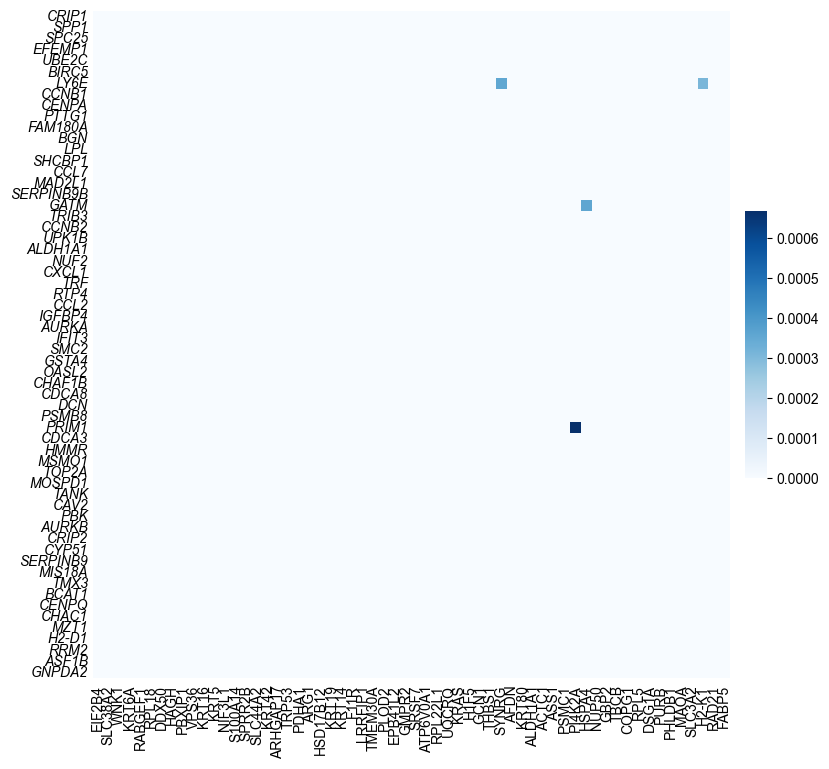

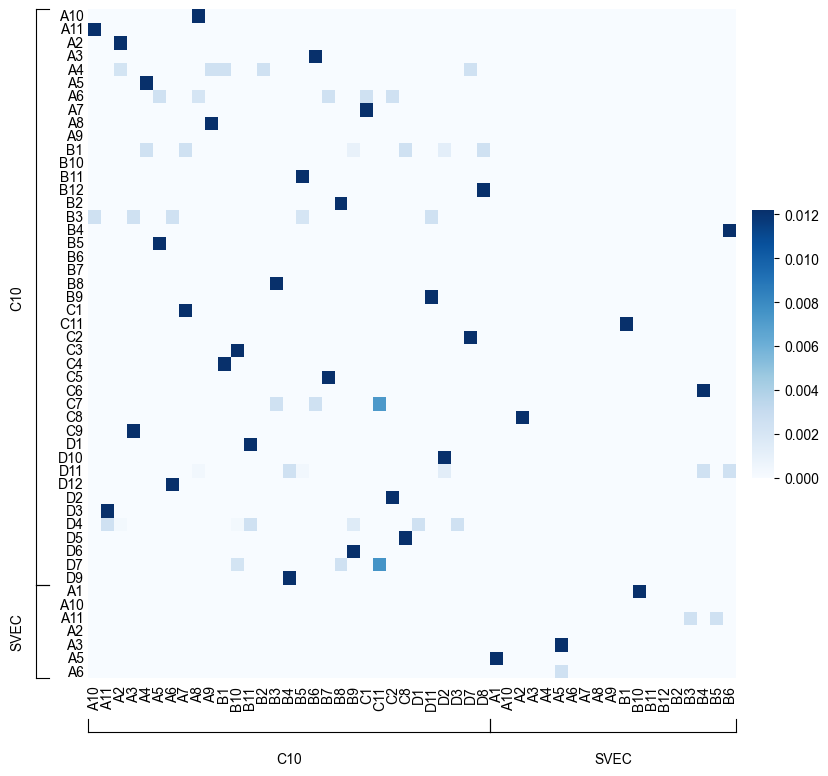

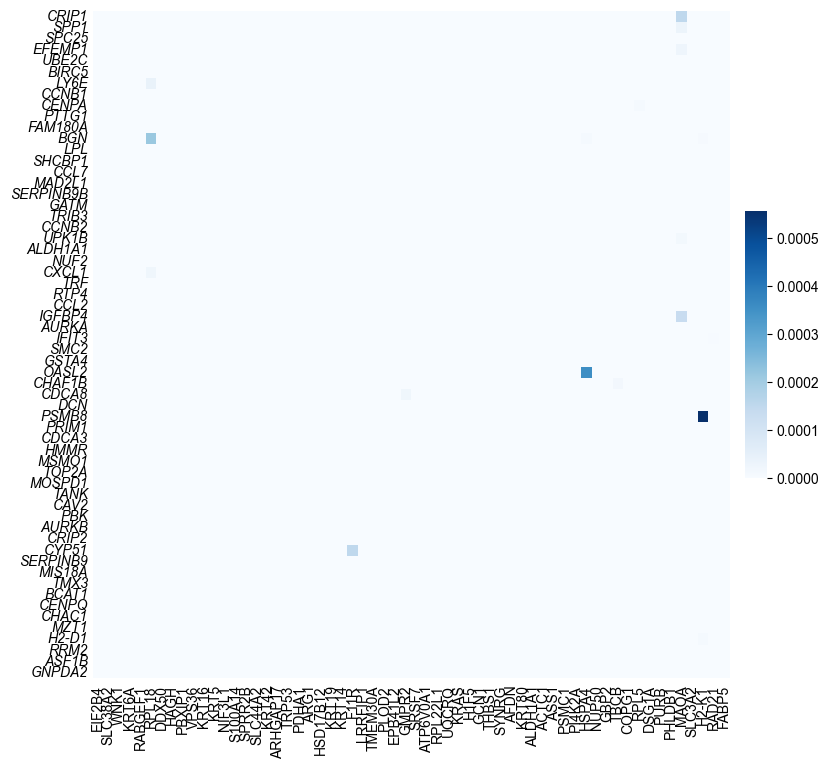

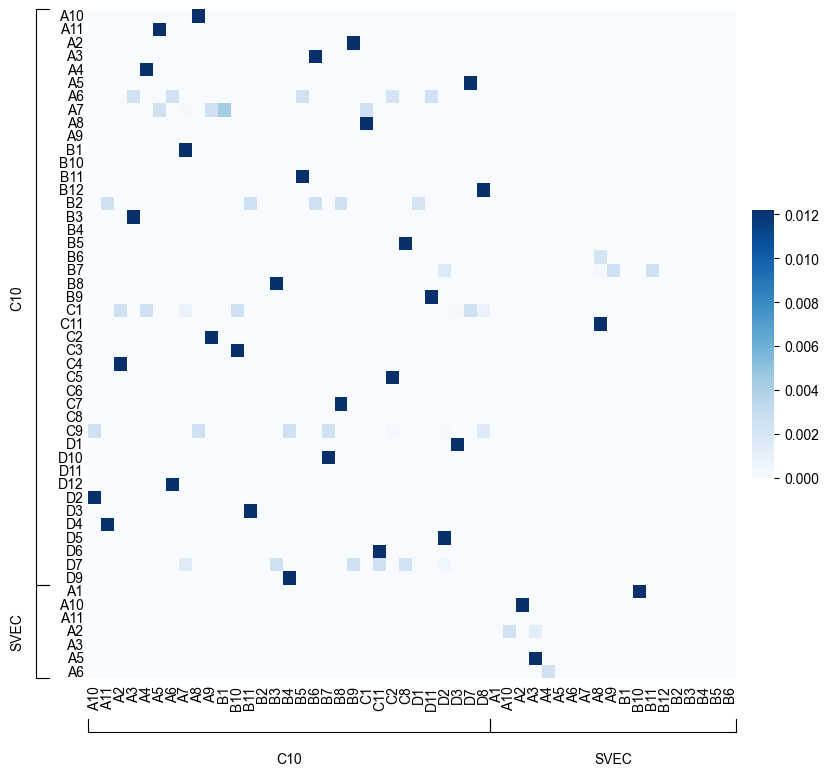

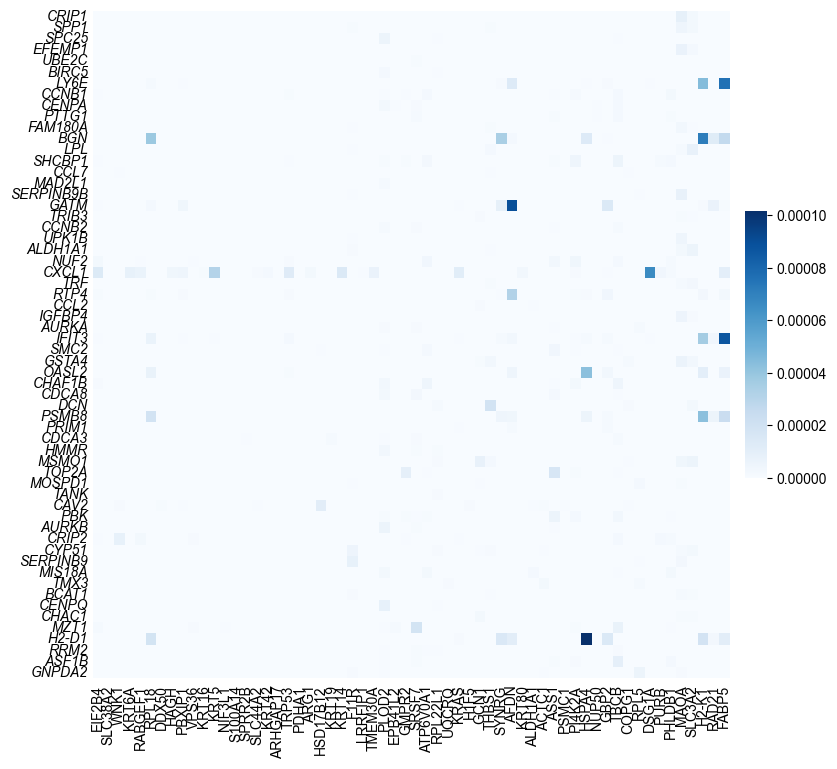

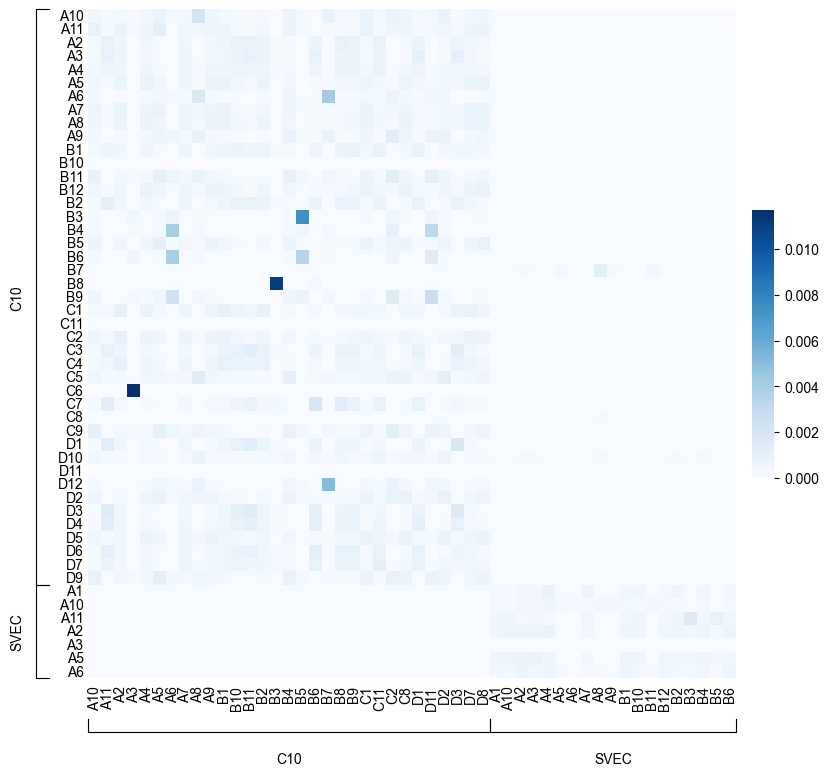

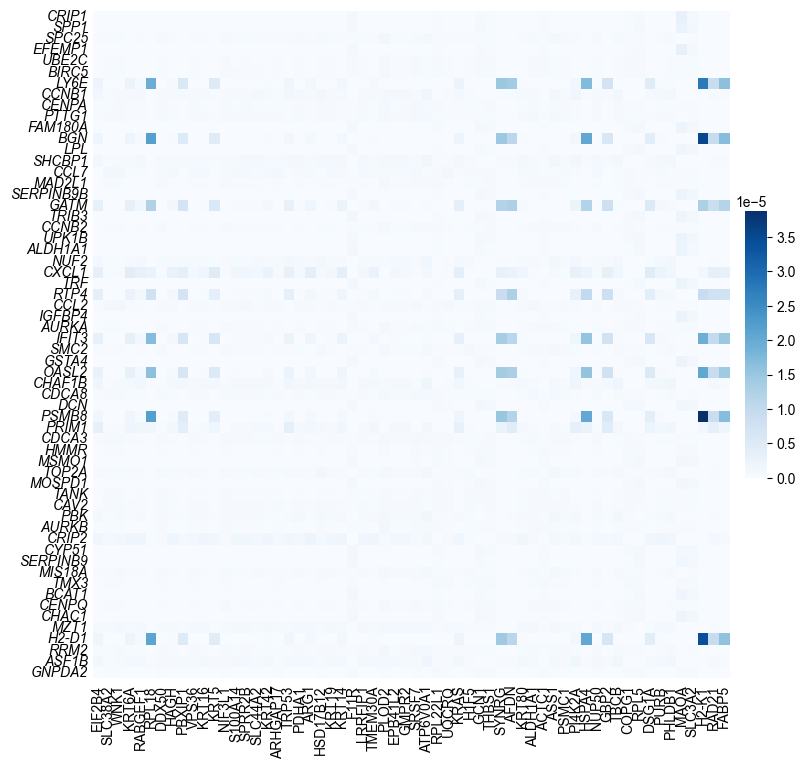

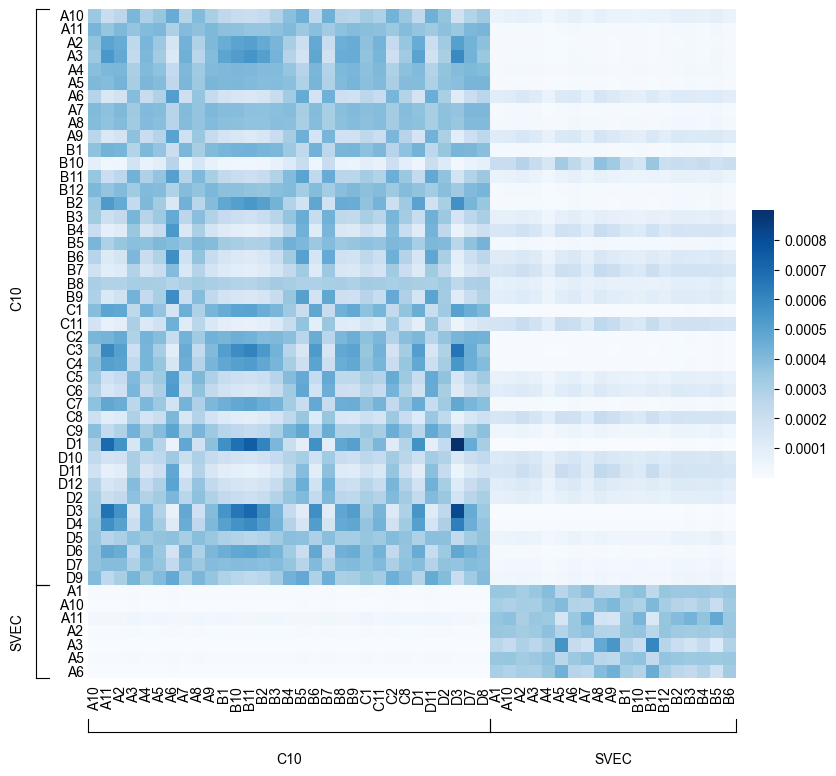

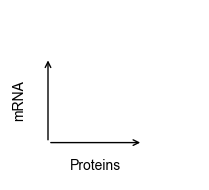

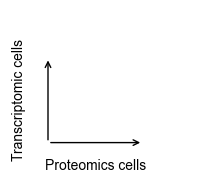

Saved individual Supplementary Figure S1 SVG components to:
C:\Users\49152\Downloads\Multi-omics\Script\For_repositories\aligned_data\Supplementary_Figure_S1_individual_heatmaps


In [29]:
# Supplementary Figure S1: epsilon coupling heatmaps

# Display controls
N_FEATURE_ROWS = 60
N_FEATURE_COLS = 60
N_SAMPLE_PLOT = 50

GENE_LABEL_FONTSIZE = 10
PROTEIN_LABEL_FONTSIZE = 10
CELL_LABEL_FONTSIZE = 10
GROUP_LABEL_FONTSIZE = 10

SHOW_FEATURE_TICK_LABELS = True
SHOW_SAMPLE_TICK_LABELS = True

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["svg.fonttype"] = "path"

def uppercase_label(x):
    return str(x).upper()


def sample_short_label(sample_id):
    sample_id = str(sample_id)
    return sample_id.split("_")[-1]


def sample_cell_type(sample_id):
    parts = str(sample_id).split("_")
    if len(parts) >= 3:
        return parts[1]
    return "Unknown"


def ordered_indices_by_cell_type(sample_ids, n_plot):
    sample_ids = np.asarray(sample_ids)
    n_plot = min(n_plot, len(sample_ids))

    selected = pd.DataFrame({"original_index": np.arange(n_plot), "sample_id": sample_ids[:n_plot]})

    selected["cell_type"] = selected["sample_id"].map(sample_cell_type)
    selected["short_label"] = selected["sample_id"].map(sample_short_label)

    selected = selected.sort_values(["cell_type", "short_label", "sample_id"], kind="stable").reset_index(drop=True)

    return selected["original_index"].to_numpy(), selected


def add_row_group_brackets(ax, ordered_metadata, x=-0.20, tick_len=0.025):
    ordered_metadata = ordered_metadata.reset_index(drop=True)
    n = ordered_metadata.shape[0]

    group_info = ordered_metadata.groupby("cell_type", sort=False).indices

    for cell_type, idxs in group_info.items():
        idxs = np.asarray(list(idxs))

        y_top = 1 - idxs.min() / n
        y_bottom = 1 - (idxs.max() + 1) / n
        y_center = (y_top + y_bottom) / 2

        # vertical line
        ax.plot([x, x], [y_bottom, y_top], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        # bracket ticks
        ax.plot([x, x + tick_len], [y_top, y_top], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        ax.plot([x, x + tick_len], [y_bottom, y_bottom], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        # group label
        ax.text(x - 0.03, y_center, str(cell_type), transform=ax.transAxes, ha="center", va="center", rotation=90, fontsize=GROUP_LABEL_FONTSIZE,
                fontweight="normal", fontfamily="Arial", clip_on=False)


def add_col_group_brackets(ax, ordered_metadata, y=-0.30, tick_len=0.025):
    ordered_metadata = ordered_metadata.reset_index(drop=True)
    n = ordered_metadata.shape[0]

    group_info = ordered_metadata.groupby("cell_type", sort=False).indices

    for cell_type, idxs in group_info.items():
        idxs = np.asarray(list(idxs))

        x_left = idxs.min() / n
        x_right = (idxs.max() + 1) / n
        x_center = (x_left + x_right) / 2

        # horizontal bracket line
        ax.plot([x_left, x_right], [y, y], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        # bracket ticks upward
        ax.plot([x_left, x_left], [y, y + tick_len], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        ax.plot([x_right, x_right], [y, y + tick_len], transform=ax.transAxes, color="black", linewidth=0.8, clip_on=False)

        # group label below the bracket
        ax.text(x_center, y - 0.030, str(cell_type), transform=ax.transAxes, ha="center", va="top", fontsize=GROUP_LABEL_FONTSIZE,
                fontweight="normal", fontfamily="Arial", clip_on=False)


def add_shared_axis_guide(ax, x_label, y_label):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    origin_x = 0.20
    origin_y = 0.22
    axis_len = 0.50

    # x-axis arrow
    ax.annotate("", xy=(origin_x + axis_len, origin_y), xytext=(origin_x, origin_y), arrowprops=dict(arrowstyle="->", linewidth=1.0))

    # y-axis arrow
    ax.annotate("", xy=(origin_x, origin_y + axis_len), xytext=(origin_x, origin_y), arrowprops=dict(arrowstyle="->", linewidth=1.0))

    ax.text(origin_x + axis_len / 2, origin_y - 0.14, x_label, ha="center", va="center", fontsize=10, fontweight="normal", fontfamily="Arial")

    ax.text(origin_x - 0.15, origin_y + axis_len / 2, y_label, ha="center", va="center", rotation=90, fontsize=10, fontweight="normal",
            fontfamily="Arial")

# Supplementary Figure S1: epsilon coupling heatmaps
PLOT_EPS_HEATMAPS_SEPARATELY = True

if PLOT_EPS_HEATMAPS_SEPARATELY:
    eps_log_file = os.path.join(OUT_DIR, "epsilon_grid_search_log.csv")

    if not os.path.exists(eps_log_file):
        raise FileNotFoundError(f"Cannot find epsilon grid-search log: {eps_log_file}. " "Run the epsilon grid-search computation block first.")

    eps_results_df = pd.read_csv(eps_log_file)

    successful = eps_results_df[eps_results_df["status"].eq("success")].copy()

    if successful.empty:
        raise RuntimeError("No successful epsilon-grid results available for plotting.")

    successful = successful.sort_values("eps").reset_index(drop=True)

    single_heatmap_dir = os.path.join(OUT_DIR, "Supplementary_Figure_S1_individual_heatmaps")
    os.makedirs(single_heatmap_dir, exist_ok=True)

    for plot_row_idx, row in successful.iterrows():
        eps_try = float(row["eps"])
        eps_tag = f"{eps_try:g}".replace(".", "p").replace("-", "m")

        npz_file = row["npz_file"]

        if not os.path.exists(npz_file):
            npz_file_alt = os.path.join(OUT_DIR, os.path.basename(str(npz_file)))
            if os.path.exists(npz_file_alt):
                npz_file = npz_file_alt
            else:
                raise FileNotFoundError(f"Missing saved coupling file: {npz_file}")

        data = np.load(npz_file)

        pi_feat_np = data["pi_feat"]
        pi_samp_np = data["pi_samp"]

        # Feature coupling heatmap
        feat_rows = min(N_FEATURE_ROWS, len(rna_features), pi_feat_np.shape[0])
        feat_cols = min(N_FEATURE_COLS, len(prot_features), pi_feat_np.shape[1])

        feat_df = pd.DataFrame(pi_feat_np[:feat_rows, :feat_cols], index=[uppercase_label(x) for x in rna_features[:feat_rows]],
                               columns=[uppercase_label(x) for x in prot_features[:feat_cols]])

        fig_feat, ax_feat = plt.subplots(figsize=(8.8, 7.8))

        sns.heatmap(feat_df, cmap="Blues", ax=ax_feat, cbar=True, xticklabels=SHOW_FEATURE_TICK_LABELS, yticklabels=SHOW_FEATURE_TICK_LABELS,
                    cbar_kws={"shrink": 0.40, "aspect": 12, "pad": 0.02})

        ax_feat.set_title("")
        ax_feat.set_xlabel("")
        ax_feat.set_ylabel("")

        ax_feat.tick_params(axis="x", labelsize=PROTEIN_LABEL_FONTSIZE, rotation=90, pad=5, length=0)

        ax_feat.tick_params(axis="y", labelsize=GENE_LABEL_FONTSIZE, rotation=0, length=0)

        for tick_label in ax_feat.get_yticklabels():
            tick_label.set_fontstyle("italic")
            tick_label.set_fontweight("normal")
            tick_label.set_fontfamily("Arial")
            
        for tick_label in ax_feat.get_xticklabels():
            tick_label.set_fontstyle("normal")
            tick_label.set_fontweight("normal")
            tick_label.set_fontfamily("Arial")
            tick_label.set_rotation(90)
            tick_label.set_ha("center")
            tick_label.set_va("top")
            tick_label.set_rotation_mode("default")
            
        fig_feat.tight_layout()

        feat_out_base = os.path.join(single_heatmap_dir, f"S1_feature_coupling_eps_{eps_tag}")

        fig_feat.savefig(f"{feat_out_base}.svg", format="svg", bbox_inches="tight")

        plt.show()
        plt.close(fig_feat)

        # Sample coupling heatmap
        rna_order_idx, rna_order_meta = ordered_indices_by_cell_type(rna_cells, N_SAMPLE_PLOT)

        prot_order_idx, prot_order_meta = ordered_indices_by_cell_type(prot_cells, N_SAMPLE_PLOT)

        samp_df = pd.DataFrame(pi_samp_np[np.ix_(rna_order_idx, prot_order_idx)], index=rna_order_meta["short_label"].to_numpy(),
                               columns=prot_order_meta["short_label"].to_numpy())

        fig_samp, ax_samp = plt.subplots(figsize=(8.8, 7.8))

        sns.heatmap(samp_df, cmap="Blues", ax=ax_samp, cbar=True, xticklabels=SHOW_SAMPLE_TICK_LABELS, yticklabels=SHOW_SAMPLE_TICK_LABELS,
                    cbar_kws={"shrink": 0.40, "aspect": 12, "pad": 0.02})

        ax_samp.set_title("")
        ax_samp.set_xlabel("")
        ax_samp.set_ylabel("")

        ax_samp.tick_params(axis="x", labelsize=CELL_LABEL_FONTSIZE, rotation=90, pad=5, length=0)

        ax_samp.tick_params(axis="y", labelsize=CELL_LABEL_FONTSIZE, rotation=0, length=0)

        for tick_label in ax_samp.get_xticklabels():
            tick_label.set_fontweight("normal")
            tick_label.set_fontfamily("Arial")
            tick_label.set_rotation(90)
            tick_label.set_ha("center")
            tick_label.set_va("top")
            tick_label.set_rotation_mode("default")
            
        for tick_label in ax_samp.get_yticklabels():
            tick_label.set_fontweight("normal")
            tick_label.set_fontfamily("Arial")

        add_row_group_brackets(ax_samp, rna_order_meta, x=-0.08, tick_len=0.020)

        add_col_group_brackets(ax_samp, prot_order_meta, y=-0.08, tick_len=0.020)

        fig_samp.tight_layout()

        samp_out_base = os.path.join(single_heatmap_dir, f"S1_sample_coupling_eps_{eps_tag}")

        fig_samp.savefig(f"{samp_out_base}.svg", format="svg", bbox_inches="tight")

        plt.show()
        plt.close(fig_samp)

    # Shared axis guides, separate SVG files
    fig_feature_guide, ax_feature_guide = plt.subplots(figsize=(2.2, 2.0))

    add_shared_axis_guide(ax_feature_guide, x_label="Proteins", y_label="mRNA")

    fig_feature_guide.tight_layout()

    feature_guide_out_base = os.path.join(single_heatmap_dir, "S1_feature_coupling_axis_guide")

    fig_feature_guide.savefig(f"{feature_guide_out_base}.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig_feature_guide)

    fig_sample_guide, ax_sample_guide = plt.subplots(figsize=(2.2, 2.0))

    add_shared_axis_guide(ax_sample_guide, x_label="Proteomics cells", y_label="Transcriptomic cells")

    fig_sample_guide.tight_layout()

    sample_guide_out_base = os.path.join(single_heatmap_dir, "S1_sample_coupling_axis_guide")

    fig_sample_guide.savefig(f"{sample_guide_out_base}.svg", format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig_sample_guide)

    print("Saved individual Supplementary Figure S1 SVG components to:")
    print(single_heatmap_dir)

In [31]:
FIG1_FONT = 10

def compute_knn_graphs(rna_mtx, prot_mtx, k, device):
    D_rna = torch.from_numpy(compute_graph_distances(rna_mtx, n_neighbors=k, mode="distance").astype("float32")).to(device)
    D_prot = torch.from_numpy(compute_graph_distances(prot_mtx, n_neighbors=k, mode="distance").astype("float32")).to(device)
    return D_rna, D_prot


def add_panel_label(ax, label, x=-0.13, y=1.08, fontsize=FIG1_FONT):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=fontsize, fontweight="normal", fontfamily="Arial", va="top", ha="left", clip_on=False)


def add_column_header(ax, text, fontsize=12):
    ax.text(0.5, 1.08, text, transform=ax.transAxes, fontsize=fontsize, va="bottom", ha="center", clip_on=False)


def scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=None, alpha_val=0.4, legend=False):
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=alpha_val, color=label_to_color[label], label=label)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)

    if panel_label is not None:
        add_panel_label(ax, panel_label)

    if legend:
        ax.legend(loc="best", frameon=False)

def plot_k_alpha_heatmap(ax, pivot_df, panel_label=None):
    plot_df = pivot_df.copy()

    # format column labels to 2 decimal places
    formatted_cols = [f"{float(c):.2f}" for c in plot_df.columns]
    plot_df.columns = formatted_cols

    sns.heatmap(plot_df, annot=True, cmap="viridis_r", ax=ax, cbar=True, annot_kws={"fontsize": FIG1_FONT, "fontfamily": "Arial", 
                                                                                    "fontweight": "normal"}, cbar_kws={"shrink": 0.40, "aspect": 12,
                                                                                                                       "pad": 0.02})

    ax.set_xlabel("alpha", fontsize=FIG1_FONT, fontfamily="Arial")
    ax.set_ylabel("k (n_neighbors)", fontsize=FIG1_FONT, fontfamily="Arial")

    ax.tick_params(axis="x", labelrotation=45, labelsize=FIG1_FONT)
    ax.tick_params(axis="y", labelsize=FIG1_FONT)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontfamily("Arial")
        tick_label.set_fontsize(FIG1_FONT)
        tick_label.set_fontweight("normal")

    # Colour-bar tick labels
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=FIG1_FONT)

    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_fontfamily("Arial")
        tick_label.set_fontsize(FIG1_FONT)
        tick_label.set_fontweight("normal")

    if panel_label is not None:
        add_panel_label(ax, panel_label, x=-0.04, y=1.04)

def plot_rna_before_after_panel(ax, Xrna_pc, Yrna_pc, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, label_to_color,
                                panel_label=None, alpha_before=0.3, alpha_after=0.7):
    for label in unique_rna_labels:
        mask_before = (rna_labels == label)
        ax.scatter(Xrna_pc[mask_before, 0], Xrna_pc[mask_before, 1], s=25, alpha=alpha_before, color=label_to_color[label], marker="o")

    for label in unique_prot_labels:
        mask_after = (prot_labels == label)
        ax.scatter(Yrna_pc[mask_after, 0], Yrna_pc[mask_after, 1], s=30, alpha=alpha_after, color=label_to_color[label], marker="^")

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

    if panel_label is not None:
        add_panel_label(ax, panel_label)


def plot_aligned_on_protein_panel(ax, prot_2Dpca, aligned_rna_prot_pca, prot_labels, rna_labels, unique_labels, label_to_color,
                                  panel_label=None, alpha_prot=0.6, alpha_aligned=0.4):
    for label in unique_labels:
        mask_prot = (prot_labels == label)
        mask_rna = (rna_labels == label)

        ax.scatter(prot_2Dpca[mask_prot, 0], prot_2Dpca[mask_prot, 1], s=25, alpha=alpha_prot, color=label_to_color[label], marker="o")

        ax.scatter(aligned_rna_prot_pca[mask_rna, 0], aligned_rna_prot_pca[mask_rna, 1], s=30, alpha=alpha_aligned, color=label_to_color[label],
                   marker="^")

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

    if panel_label is not None:
        add_panel_label(ax, panel_label)

def make_cellline_handles(unique_labels, label_to_color, markersize=6):
    return [
        Line2D([], [], linestyle="", marker="o", markersize=markersize, color=label_to_color[label], label=str(label)) for label in unique_labels]


def make_before_after_handles(markersize=6):
    return [Line2D([], [], linestyle="", marker="o", markersize=markersize, color="black", label="Before alignment"),
            Line2D([], [], linestyle="", marker="^", markersize=markersize, color="black", label="After alignment")]


def format_pca_axis(ax, show_ylabel=True, show_xlabel=False):
    ax.set_xlabel("PC1" if show_xlabel else "", fontsize=FIG1_FONT, fontfamily="Arial")
    ax.set_ylabel("PC2" if show_ylabel else "", fontsize=FIG1_FONT, fontfamily="Arial")
    ax.tick_params(labelsize=FIG1_FONT)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontfamily("Arial")
        tick_label.set_fontsize(FIG1_FONT)
        tick_label.set_fontweight("normal")

def add_shared_pc1_label(fig, y=0.04, x0=0.12, x1=0.84, fontsize=FIG1_FONT):
    line_y = y + 0.035

    fig.add_artist(Line2D([x0, x1], [line_y, line_y], transform=fig.transFigure, color="black", linewidth=0.8, clip_on=False))

    fig.text((x0 + x1) / 2, y, "PC1", ha="center", va="center", fontsize=fontsize, fontfamily="Arial", fontweight="normal")


def plot_cellline_pca(ax, emb, labels, unique_labels, label_to_color, alpha_val=0.45):
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            ax.scatter(emb[mask, 0], emb[mask, 1], s=22, alpha=alpha_val, color=label_to_color[label], label=str(label), edgecolors="none")

    format_pca_axis(ax, show_ylabel=True, show_xlabel=False)

def plot_before_after_alpha_panel(ax, Xrna_pc, Yrna_pc, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, label_to_color, alpha_value,
                                  alpha_before=0.30, alpha_after=0.70):
    for label in unique_rna_labels:
        mask_before = rna_labels == label
        ax.scatter(Xrna_pc[mask_before, 0], Xrna_pc[mask_before, 1], s=24, alpha=alpha_before, color=label_to_color[label], marker="o",
                   edgecolors="none")

    for label in unique_prot_labels:
        mask_after = prot_labels == label
        ax.scatter(Yrna_pc[mask_after, 0], Yrna_pc[mask_after, 1], s=28, alpha=alpha_after, color=label_to_color[label], marker="^",
                   edgecolors="none")

    ax.text(0.97, 0.95, rf"$\alpha = {alpha_value}$", transform=ax.transAxes, ha="right", va="top", fontsize=FIG1_FONT, fontfamily="Arial",
            fontweight="normal")

    format_pca_axis(ax, show_ylabel=True, show_xlabel=False)


def plot_protein_space_alpha_panel(ax, prot_2Dpca, aligned_rna_prot_pca, prot_labels, rna_labels, unique_labels, label_to_color, alpha_value,
                                   alpha_prot=0.60, alpha_aligned=0.40):
    for label in unique_labels:
        mask_prot = prot_labels == label
        mask_rna = rna_labels == label

        ax.scatter(prot_2Dpca[mask_prot, 0], prot_2Dpca[mask_prot, 1], s=24, alpha=alpha_prot, color=label_to_color[label], marker="o",
                   edgecolors="none")

        ax.scatter(aligned_rna_prot_pca[mask_rna, 0], aligned_rna_prot_pca[mask_rna, 1], s=28, alpha=alpha_aligned, color=label_to_color[label],
                   marker="^", edgecolors="none")

    ax.text(0.97, 0.95, rf"$\alpha = {alpha_value}$", transform=ax.transAxes, ha="right", va="top", fontsize=FIG1_FONT, fontfamily="Arial",
            fontweight="normal")

    format_pca_axis(ax, show_ylabel=True, show_xlabel=False)


def save_figure1B(out_base, rna_2Dpca, prot_2Dpca, rna_labels, prot_labels, unique_labels, label_to_color):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    plot_cellline_pca(axes[0], rna_2Dpca, rna_labels, unique_labels, label_to_color, alpha_val=0.45)
    plot_cellline_pca(axes[1], prot_2Dpca, prot_labels, unique_labels, label_to_color, alpha_val=0.45)

    add_panel_label(axes[0], "B", x=-0.18, y=1.12, fontsize=16)

    handles = make_cellline_handles(unique_labels, label_to_color)

    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.86, 0.50), frameon=False, fontsize=FIG1_FONT)
    axes[1].set_ylabel("")
    fig.tight_layout(rect=[0, 0.08, 0.86, 1])
    add_shared_pc1_label(fig, y=0.035, x0=0.10, x1=0.82, fontsize=12)

    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_figure1D(out_base, selected_alpha_panels, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, unique_labels, label_to_color,
                  alpha_order=(0.9, 0.6, 0.3)):
    fig, axes = plt.subplots(1, len(alpha_order), figsize=(14, 4.2))

    for i, alpha_val in enumerate(alpha_order):
        panel_data = selected_alpha_panels[alpha_val]

        plot_before_after_alpha_panel(axes[i], panel_data["Xrna_pc"], panel_data["Yrna_pc"], rna_labels, prot_labels, unique_rna_labels,
                                      unique_prot_labels, label_to_color, alpha_value=alpha_val)

    for ax in axes[1:]:
        ax.set_ylabel("")

    add_panel_label(axes[0], "C", x=-0.18, y=1.12, fontsize=16)

    handles = (make_cellline_handles(unique_labels, label_to_color) + make_before_after_handles())

    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.86, 0.50), frameon=False, fontsize=FIG1_FONT)
    fig.tight_layout(rect=[0, 0.08, 0.86, 1])
    add_shared_pc1_label(fig, y=0.035, x0=0.08, x1=0.82, fontsize=12)

    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_figure1E(out_base, selected_alpha_panels, prot_2Dpca, prot_labels, rna_labels, unique_labels, label_to_color, alpha_order=(0.9, 0.6, 0.3)):
    fig, axes = plt.subplots(1, len(alpha_order), figsize=(14, 4.2))

    for i, alpha_val in enumerate(alpha_order):
        panel_data = selected_alpha_panels[alpha_val]

        plot_protein_space_alpha_panel(axes[i], prot_2Dpca, panel_data["aligned_rna_prot_pca"], prot_labels, rna_labels, unique_labels,
                                       label_to_color, alpha_value=alpha_val)

    for ax in axes[1:]:
        ax.set_ylabel("")
    
    add_panel_label(axes[0], "D", x=-0.18, y=1.12, fontsize=16)

    handles = (make_cellline_handles(unique_labels, label_to_color) + make_before_after_handles())

    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.86, 0.50), frameon=False, fontsize=FIG1_FONT)
    fig.tight_layout(rect=[0, 0.08, 0.86, 1])
    add_shared_pc1_label(fig, y=0.035, x0=0.08, x1=0.82, fontsize=12)

    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_figure1F(out_base, fracs, rand_fracs, mean_fos, mean_rand):
    fig, ax = plt.subplots(figsize=(6.4, 4.6))

    ax.plot(np.arange(len(fracs)), np.sort(fracs), linestyle="--", color="black", label=f"AGW alignment (mean={mean_fos:.3f})")

    ax.plot(np.arange(len(rand_fracs)), np.sort(rand_fracs), linestyle=":", color="black", label=f"Random alignment (mean={mean_rand:.3f})")

    ax.set_xlabel("Cells", fontsize=FIG1_FONT, fontfamily="Arial")
    ax.set_ylabel("Sorted FOSCTTM", fontsize=FIG1_FONT, fontfamily="Arial")
    ax.tick_params(labelsize=FIG1_FONT)
    
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontfamily("Arial")
        tick_label.set_fontsize(FIG1_FONT)
        tick_label.set_fontweight("normal")
    
    ax.legend(frameon=False, fontsize=FIG1_FONT)

    add_panel_label(ax, "E", x=-0.12, y=1.08, fontsize=16)

    fig.tight_layout()

    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [33]:
#Existing PCA / labels setup
unique_labels = list(np.unique(np.concatenate([rna_labels, prot_labels])))
unique_rna_labels = np.unique(rna_labels)
unique_prot_labels = np.unique(prot_labels)

# Colourblind-friendly contrasting colours
label_to_color = {}

for label in unique_labels:
    if str(label).upper() == "C10":
        label_to_color[label] = "#0072B2"   # blue
    elif str(label).upper() == "SVEC":
        label_to_color[label] = "#D55E00"   # orange
    else:
        label_to_color[label] = "gray"

#Grid search settings
RUN_GRID_SEARCH = True
manual_k = 10
alpha_compare = [0.9, 0.6, 0.3]
k_grid = [5, 10, 15, 20]
alpha_grid = np.linspace(0.01, 0.99, 10)

#Shared index maps for FOSCTTM
rna_idx_map = {sid: i for i, sid in enumerate(rna_cells)}
prot_idx_map = {sid: i for i, sid in enumerate(prot_cells)}

rna_common_idx = np.array([rna_idx_map[sid] for sid in common_true])
prot_common_idx = np.array([prot_idx_map[sid] for sid in common_true])

results_df = pd.DataFrame()

#Grid search over k and alpha using FOSCTTM
if RUN_GRID_SEARCH:
    print("Running grid search over k and alpha...")

    results = []

    for k in k_grid:
        print(f"\nEvaluating k = {k}")
        D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, k, device)

        for alpha in alpha_grid:
            try:
                pi_samp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=alpha, eps=eps, verbose=False)

                aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
                aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

                rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
                prot_common = prot_mtx[prot_common_idx, :]

                fracs = FOSCTTM(prot_common, rna_common)
                mean_fos = float(np.mean(fracs))

                results.append({"k": k, "alpha": float(alpha), "foscttm": mean_fos})

                print(f"k={k}, alpha={alpha:.3f}, FOSCTTM={mean_fos:.4f}")

            except Exception as e:
                print(f"Failed for k={k}, alpha={alpha}: {e}")

    results_df = pd.DataFrame(results)

    if results_df.empty:
        raise RuntimeError("Grid search ran but produced no valid results.")

    results_df.to_csv(os.path.join(OUT_DIR, "k_alpha_grid_search.csv"), index=False)

    best_row = results_df.loc[results_df["foscttm"].idxmin()]
    best_k = int(best_row["k"])
    print("\nBest k from grid search:", best_k)

else:
    print("Skipping grid search. Using manually specified k.")
    best_k = manual_k

print(f"\nSelected k for downstream comparisons: {best_k}")
print(f"Fixed eps: {eps}")

#Build pivot heatmap using the selected k
if results_df.empty:
    # If no grid search run in this session, compute the full k x alpha heatmap
    heatmap_results = []

    print("\nComputing full k x alpha heatmap values...")
    for k in k_grid:
        D_rna_heat, D_prot_heat = compute_knn_graphs(rna_mtx, prot_mtx, k, device)

        for alpha in alpha_grid:
            try:
                pi_samp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_heat, D_prot_heat, alpha=alpha, eps=eps, verbose=False)

                aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
                aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

                rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
                prot_common = prot_mtx[prot_common_idx, :]

                fracs = FOSCTTM(prot_common, rna_common)
                mean_fos = float(np.mean(fracs))

                heatmap_results.append({"k": k, "alpha": float(alpha), "foscttm": mean_fos})

            except Exception as e:
                print(f"Failed for k={k}, alpha={alpha}: {e}")

    heatmap_df = pd.DataFrame(heatmap_results)
else:
    heatmap_df = results_df.copy()

if heatmap_df.empty:
    raise RuntimeError("No valid alpha heatmap results available for Figure 1C.")

pivot = (heatmap_df.sort_values(["k", "alpha"]).pivot(index="k", columns="alpha", values="foscttm"))

Running grid search over k and alpha...

Evaluating k = 5
k=5, alpha=0.010, FOSCTTM=0.4167
k=5, alpha=0.119, FOSCTTM=0.3919
k=5, alpha=0.228, FOSCTTM=0.3839
k=5, alpha=0.337, FOSCTTM=0.3320
k=5, alpha=0.446, FOSCTTM=0.3120
k=5, alpha=0.554, FOSCTTM=0.3008
k=5, alpha=0.663, FOSCTTM=0.2848
k=5, alpha=0.772, FOSCTTM=0.2675
k=5, alpha=0.881, FOSCTTM=0.2533
k=5, alpha=0.990, FOSCTTM=0.2568

Evaluating k = 10
k=10, alpha=0.010, FOSCTTM=0.4139
k=10, alpha=0.119, FOSCTTM=0.3975
k=10, alpha=0.228, FOSCTTM=0.3805
k=10, alpha=0.337, FOSCTTM=0.3332
k=10, alpha=0.446, FOSCTTM=0.3105
k=10, alpha=0.554, FOSCTTM=0.3105
k=10, alpha=0.663, FOSCTTM=0.3020
k=10, alpha=0.772, FOSCTTM=0.2794
k=10, alpha=0.881, FOSCTTM=0.2653
k=10, alpha=0.990, FOSCTTM=0.2477

Evaluating k = 15
k=15, alpha=0.010, FOSCTTM=0.4186
k=15, alpha=0.119, FOSCTTM=0.4134
k=15, alpha=0.228, FOSCTTM=0.3825
k=15, alpha=0.337, FOSCTTM=0.3477
k=15, alpha=0.446, FOSCTTM=0.3180
k=15, alpha=0.554, FOSCTTM=0.3077
k=15, alpha=0.663, FOSCTTM=0.2

In [35]:
#Alpha comparison diagnostics
alpha_plot_dir = os.path.join(OUT_DIR, "alpha_comparison_plots")
os.makedirs(alpha_plot_dir, exist_ok=True)

D_rna_cmp, D_prot_cmp = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

alpha_summary = []
selected_alphas = [0.9, 0.6, 0.3]
selected_alpha_panels = {}

for alpha_cmp in alpha_compare:
    print(f"\nGenerating comparison data for alpha = {alpha_cmp}")

    pi_samp_cmp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_cmp, D_prot_cmp, alpha=alpha_cmp, eps=eps, verbose=False)

    # RNA feature space on proteomics sample axis
    aligned_rna_rna_space = get_barycentre(rna_mtx, pi_samp_cmp.T, device=device)
    aligned_rna_rna_space_np = aligned_rna_rna_space.detach().cpu().numpy()

    # Protein feature space on RNA sample axis
    aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp_cmp, device=device)
    aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

    # FOSCTTM
    rna_common_cmp = aligned_rna_prot_space_np[rna_common_idx, :]
    prot_common_cmp = prot_mtx[prot_common_idx, :]

    fracs_cmp = FOSCTTM(prot_common_cmp, rna_common_cmp)
    mean_fos_cmp = float(np.mean(fracs_cmp))

    alpha_summary.append({"alpha": alpha_cmp, "k": best_k, "eps": eps, "foscttm": mean_fos_cmp})

    # Project into PCA spaces
    Xrna_pc = rna_pca.transform(rna_mtx)
    Yrna_pc = rna_pca.transform(aligned_rna_rna_space_np)
    aligned_rna_prot_pca = prot_pca.transform(aligned_rna_prot_space_np)

    # Save selected panels
    if alpha_cmp in selected_alphas:
        selected_alpha_panels[alpha_cmp] = {"Xrna_pc": Xrna_pc, "Yrna_pc": Yrna_pc, "aligned_rna_prot_pca": aligned_rna_prot_pca}

    # Optional: save standalone 2-panel diagnostic figures for each alpha
    for ext in ["svg"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        scatter_before = 0.3
        scatter_after = 0.7
        scatter_prot = 0.6
        scatter_aligned = 0.4

        plot_rna_before_after_panel(axes[0], Xrna_pc, Yrna_pc, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, label_to_color,
                                    alpha_before=scatter_before, alpha_after=scatter_after)

        plot_aligned_on_protein_panel(axes[1], prot_2Dpca, aligned_rna_prot_pca, prot_labels, rna_labels, unique_labels, label_to_color,
                                      alpha_prot=scatter_prot, alpha_aligned=scatter_aligned)

        fig.tight_layout()
        fig.savefig(os.path.join(alpha_plot_dir, f"alpha_{alpha_cmp}_comparison.{ext}"), format=ext, bbox_inches="tight")
        plt.close(fig)

alpha_summary_df = pd.DataFrame(alpha_summary)
alpha_summary_df.to_csv(os.path.join(alpha_plot_dir, "alpha_comparison_summary.csv"), index=False)

print("\nAlpha comparison summary:")
print(alpha_summary_df)

missing_needed = [a for a in selected_alphas if a not in selected_alpha_panels]
if missing_needed:
    raise RuntimeError(f"Missing selected alpha panels for Figure 2: {missing_needed}")


Generating comparison data for alpha = 0.9

Generating comparison data for alpha = 0.6

Generating comparison data for alpha = 0.3

Alpha comparison summary:
   alpha   k    eps   foscttm
0    0.9  10  0.045  0.262842
1    0.6  10  0.045  0.306967
2    0.3  10  0.045  0.363661



Running final alignment with selected parameters:
eps = 0.045
k = 10
alpha = 0.6
BCD Iteration 1 - Loss: 0.764336, 0.812731
BCD Iteration 2 - Loss: 0.735820, 0.801227
BCD Iteration 3 - Loss: 0.726422, 0.799406
BCD Iteration 4 - Loss: 0.720626, 0.798357
BCD Iteration 5 - Loss: 0.716690, 0.797577
BCD Iteration 6 - Loss: 0.714544, 0.797193
BCD Iteration 7 - Loss: 0.713106, 0.796972
BCD Iteration 8 - Loss: 0.711565, 0.796709
BCD Iteration 9 - Loss: 0.709889, 0.796458
BCD Iteration 10 - Loss: 0.708790, 0.796356
BCD Iteration 11 - Loss: 0.707913, 0.796279
BCD Iteration 12 - Loss: 0.707027, 0.796201
BCD Iteration 13 - Loss: 0.706305, 0.796152
BCD Iteration 14 - Loss: 0.705799, 0.796122
BCD Iteration 15 - Loss: 0.705401, 0.796095

Running final FOSCTTM evaluation...
Mean FOSCTTM: 0.306967213114754
Random baseline: 0.5913934426229507


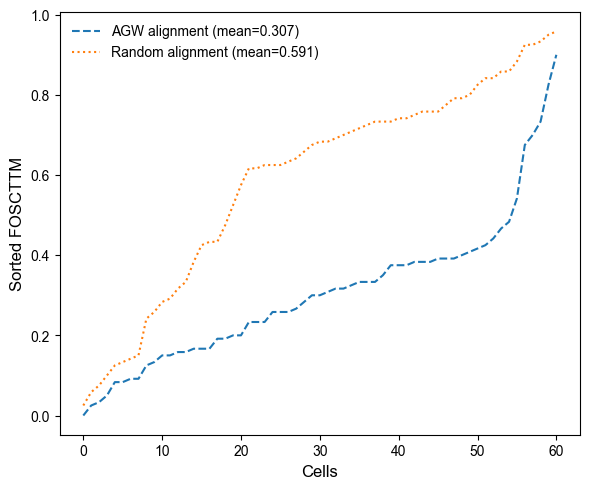

In [37]:
# Final alignment, define alpha after inspecting the alpha comparison plots
final_alpha = 0.6

# Safety check
if not (0 <= final_alpha <= 1):
    raise ValueError(f"final_alpha must be between 0 and 1, got {final_alpha}")

if final_alpha not in alpha_compare:
    print(f"Warning: final_alpha={final_alpha} was not included in alpha_compare={alpha_compare}")

print("\nRunning final alignment with selected parameters:")
print(f"eps = {eps}")
print(f"k = {best_k}")
print(f"alpha = {final_alpha}")

#Recompute graph distances using the selected k
D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

#Run final AGW alignment
pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=final_alpha, eps=eps, verbose=True)

#FOSCTTM evaluation based on the selected alpha
print("\nRunning final FOSCTTM evaluation...")

#Aligned RNA in protein feature space on RNA sample axis
aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

#Compute FOSCTTM on true paired samples
rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
prot_common = prot_mtx[prot_common_idx, :]

fracs = FOSCTTM(prot_common, rna_common)
mean_fos = float(np.mean(fracs))

# Random baseline
perm = np.random.permutation(len(prot_common))
rand_fracs = FOSCTTM(prot_common[perm], rna_common)
mean_rand = float(np.mean(rand_fracs))

print("Mean FOSCTTM:", mean_fos)
print("Random baseline:", mean_rand)

# Standalone FOSCTTM plot
for ext in ["svg"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(np.arange(len(fracs)), np.sort(fracs), linestyle="--", label=f"AGW alignment (mean={mean_fos:.3f})")
    ax.plot(np.arange(len(rand_fracs)), np.sort(rand_fracs), linestyle=":", label=f"Random alignment (mean={mean_rand:.3f})")
    ax.set_xlabel("Cells", fontsize=12)
    ax.set_ylabel("Sorted FOSCTTM", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.legend(frameon=False, fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"FOSCTTM_final.{ext}"), format=ext, bbox_inches="tight")
    plt.show()
    plt.close(fig)

final_foscttm_df = pd.DataFrame([{"alpha": final_alpha, "k": best_k, "eps": eps, "mean_foscttm": mean_fos, "random_baseline": mean_rand}])

final_foscttm_df.to_csv(os.path.join(OUT_DIR, "final_foscttm_summary.csv"), index=False)

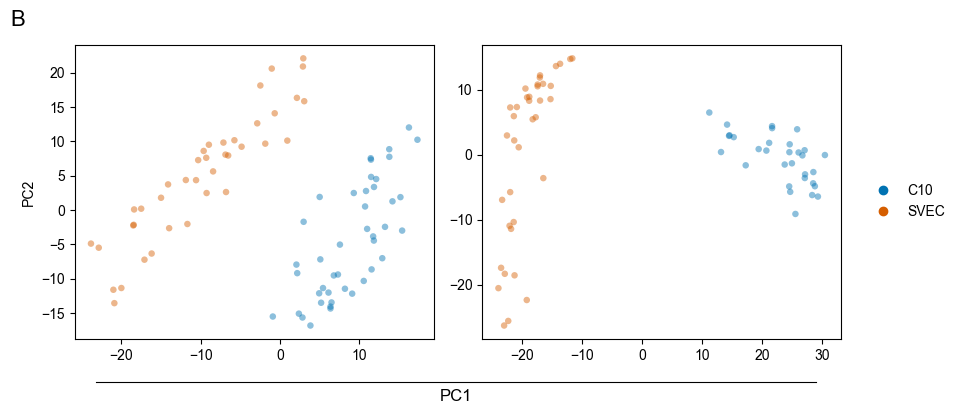

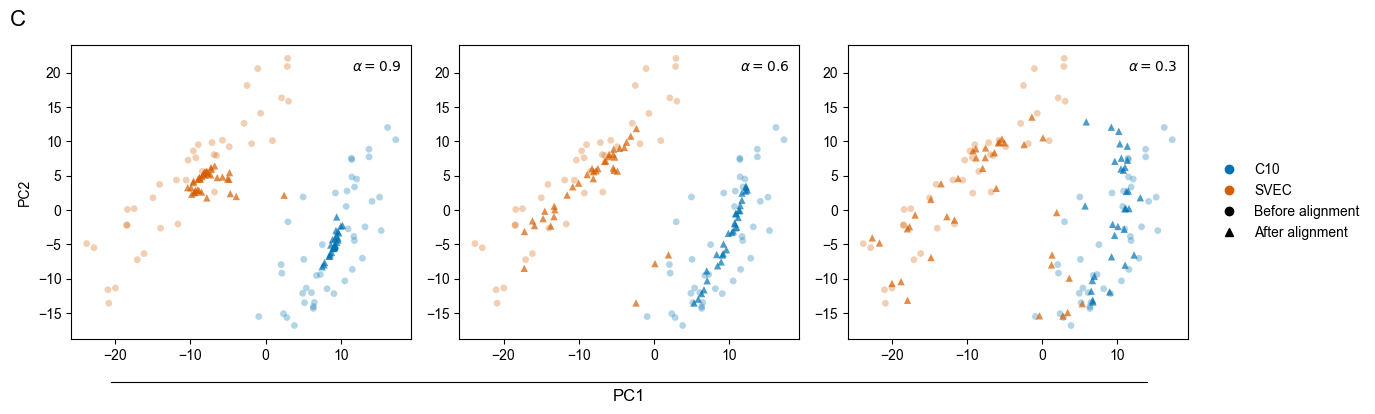

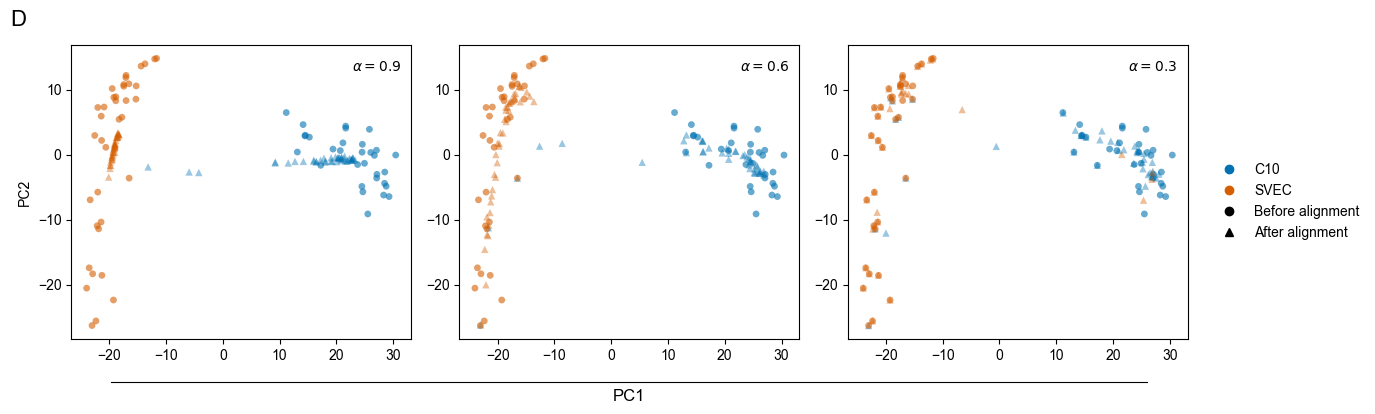

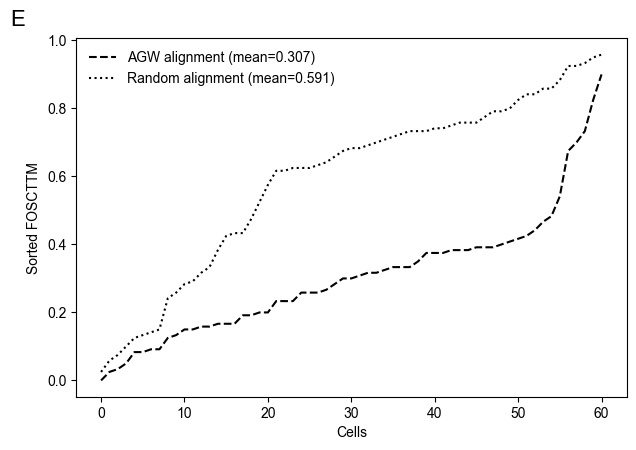

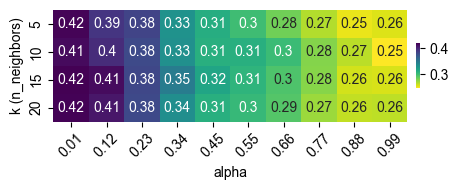

In [39]:
# Figure 1 components: SVG only
save_figure1B(out_base=os.path.join(OUT_DIR, "Figure_1B_pre_alignment_PCA"), rna_2Dpca=rna_2Dpca, prot_2Dpca=prot_2Dpca, rna_labels=rna_labels,
              prot_labels=prot_labels, unique_labels=unique_labels, label_to_color=label_to_color)

save_figure1D(out_base=os.path.join(OUT_DIR, "Figure_1D_alignment_on_transcriptomic_PCA"), selected_alpha_panels=selected_alpha_panels,
              rna_labels=rna_labels, prot_labels=prot_labels, unique_rna_labels=unique_rna_labels, unique_prot_labels=unique_prot_labels,
              unique_labels=unique_labels, label_to_color=label_to_color, alpha_order=(0.9, 0.6, 0.3))

save_figure1E(out_base=os.path.join(OUT_DIR, "Figure_1E_alignment_on_proteomic_PCA"), selected_alpha_panels=selected_alpha_panels,
              prot_2Dpca=prot_2Dpca, prot_labels=prot_labels, rna_labels=rna_labels, unique_labels=unique_labels, label_to_color=label_to_color,
              alpha_order=(0.9, 0.6, 0.3))

save_figure1F(out_base=os.path.join(OUT_DIR, "Figure_1F_FOSCTTM"), fracs=fracs, rand_fracs=rand_fracs, mean_fos=mean_fos, mean_rand=mean_rand)


#Figure 1C - heatmap
fig, ax = plt.subplots(figsize=(5, 2))
plot_k_alpha_heatmap(ax, pivot, panel_label=None)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "Figure_1C_k_alpha_heatmap.svg"), format="svg", bbox_inches="tight")
plt.show()
plt.close(fig)

In [41]:
# Preparation of MOFA matrices
print("\nPreparing MOFA-ready matrices...")

# RNA projected onto proteomics sample axis, retaining RNA features
rna_on_prot_sample_axis = get_barycentre(rna_mtx, pi_samp.T, device=device)
rna_on_prot_sample_axis_np = rna_on_prot_sample_axis.detach().cpu().numpy()

# Build RNA dataframe
aligned_rna_df = pd.DataFrame(rna_on_prot_sample_axis_np, index=prot_cells, columns=rna_features).T

# Proteomics dataframe
prot_df_for_mofa = pd.DataFrame(prot_mtx, index=prot_cells, columns=prot_features).T
print("\nMOFA-ready aligned RNA shape (features x samples):", aligned_rna_df.shape)
print("MOFA-ready proteomics shape (features x samples):", prot_df_for_mofa.shape)

# Consistency check
if not aligned_rna_df.columns.equals(prot_df_for_mofa.columns):
    raise ValueError("Aligned RNA and proteomics views do not share identical sample axis for MOFA.")

# Centering, since MOFA expects roughly centered Gaussian data
aligned_rna_centered = aligned_rna_df.sub(aligned_rna_df.mean(axis=1), axis=0).astype(np.float32)
prot_centered = prot_df_for_mofa.sub(prot_df_for_mofa.mean(axis=1), axis=0).astype(np.float32)


Preparing MOFA-ready matrices...

MOFA-ready aligned RNA shape (features x samples): (1500, 68)
MOFA-ready proteomics shape (features x samples): (1500, 68)


In [43]:
# Export MOFA inputs
print("\nExporting MOFA inputs and alignment outputs...")
aligned_rna_centered.to_csv(os.path.join(OUT_DIR, "aligned_transcriptomics.csv"), index_label="Gene")

prot_centered.to_csv(os.path.join(OUT_DIR, "aligned_proteomics.csv"), index_label="Gene")

# Metadata alignment
if "SampleID" in prot_meta.columns:
    prot_meta_indexed = prot_meta.set_index("SampleID")
else:
    prot_meta_indexed = prot_meta.copy()

# Align metadata to proteomics sample axis
missing_samples = set(prot_cells) - set(prot_meta_indexed.index)
if len(missing_samples) > 0:
    raise ValueError(f"Missing metadata for samples: {missing_samples}")

aligned_metadata = prot_meta_indexed.loc[prot_cells].copy()
aligned_metadata.index.name = "SampleID"
aligned_metadata.to_csv(os.path.join(OUT_DIR, "aligned_metadata.csv"))

# Save coupling matrices
pi_samp_np = pi_samp.detach().cpu().numpy()
pi_feat_np = pi_feat.detach().cpu().numpy()

pd.DataFrame(pi_samp_np, index=rna_cells, columns=prot_cells).to_csv(os.path.join(OUT_DIR, "sample_coupling_matrix.csv"))

pd.DataFrame(pi_feat_np, index=rna_features, columns=prot_features).to_csv(os.path.join(OUT_DIR, "feature_coupling_matrix.csv"))

# Save final parameters
final_config = pd.DataFrame([{
    "alpha": final_alpha,
    "k": best_k,
    "eps": eps,
    "n_rna_cells": len(rna_cells),
    "n_prot_cells": len(prot_cells),
    "n_common_pairs": len(common_true)
}])

final_config.to_csv(os.path.join(OUT_DIR, "scot_alignment_config.csv"), index=False)

print("\nSCOT+ alignment complete.")
print("Saved MOFA-ready files to:", OUT_DIR)
print("Saved alignment diagnostics and configuration.")


Exporting MOFA inputs and alignment outputs...

SCOT+ alignment complete.
Saved MOFA-ready files to: C:\Users\49152\Downloads\Multi-omics\Script\For_repositories\aligned_data
Saved alignment diagnostics and configuration.
